# TOV Solver (with Tidal ODEs) for simple polytropic "POLYn1" EoS

## Solver

In [1]:
## The TOV Solver ##
#------------------#
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from scipy.integrate import ode
import pandas as pd

#TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, rho):
    if r <= 0:
        return 0
    return -(rho + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
    
def dm_dr(r, p, m, rho):
    return 4 * pi * r**2 * rho
    
def dy2_dr(r, y2, p, m, rho, cs2):
    if r<=1e-6:
        return 2
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-2*(2+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y2**2/r + y2*F + r*G)
    
def tov_equations(r, state, eos_rho, eos_cs2):
    p, m, y2 = state
    rho = eos_rho(p)
    cs2 = eos_cs2(rho)
    return [
        dp_dr(r, p, m, rho),
        dm_dr(r, p, m, rho),
        dy2_dr(r, y2, p, m, rho, cs2)
    ]

#TOV integrator, from r=0 outwards, until p=0 (we yield r=R)

def solve_tov_equations(p_central, eos_rho, eos_cs2, step):
    r_initial = 1e-6
    state_initial = [ p_central, 0., 2 ]
    
    integrator = ode(tov_equations).set_integrator('dopri5')
    integrator.set_initial_value(state_initial, r_initial)
    integrator.set_f_params(eos_rho, eos_cs2)
    
    r_path = []
    p_path = []
    m_path = []
    y2_path = []

    while integrator.successful():
        integrator.integrate(integrator.t + step)

        r = integrator.t
        p, m, y2 = integrator.y 

        r_path.append(r)
        p_path.append(p)
        m_path.append(m)
        y2_path.append(y2)

        if p < 0:
            break
    return (np.array(r_path),
            np.array(p_path),
            np.array(m_path),
            np.array(y2_path)
        )


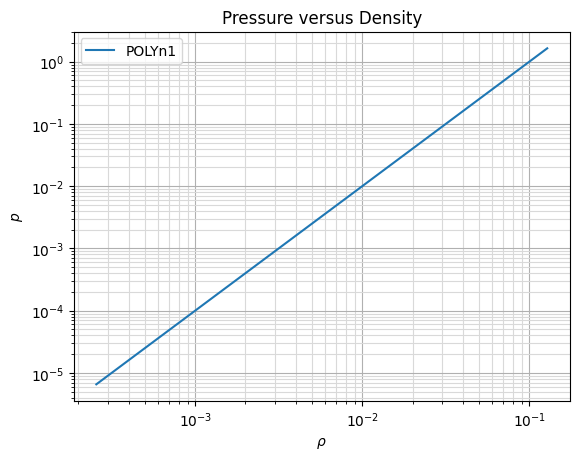

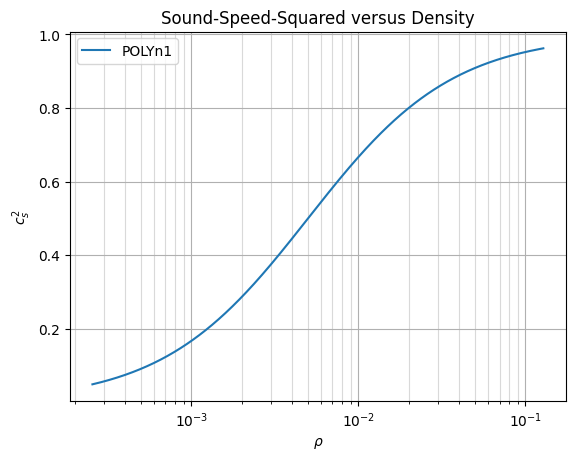

In [2]:
# EoS: Simple Polytrope
#-----------------------#

def eos_p(rho, K, Gamma):
    return K * rho**Gamma

def eos_rho(p, K, Gamma):
    rho_rest = (p / K)**(1/Gamma)
    return rho_rest + p/(Gamma-1)

def eos_cs2(rho, K, Gamma):
    dpdrho = Gamma * K * rho**(Gamma - 1)
    dedrho = 1 + dpdrho/(Gamma - 1)
    return dpdrho / dedrho

# Create an EOS function
def POLYn1_eos_p_and_rho():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_p(rho, K, Gamma),
        lambda p: eos_rho(p, K, Gamma),
    )

def POLYn1_eos_cs2_and_rho():
    K = 100
    Gamma = 2
    return (
        lambda rho: eos_cs2(rho, K, Gamma),
        lambda p: eos_rho(p, K, Gamma),
    )

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 100 * rho_base
rho_c_space = np.logspace(np.log10(rho_min),
                          np.log10(rho_max), 1000)

# Plot the EOS
f1=plt.figure()
plt.loglog(rho_c_space, eos_p_func(rho_c_space), label="POLYn1")
plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

f2=plt.figure()
eos_cs2_func, _ = POLYn1_eos_cs2_and_rho()
plt.semilogx(rho_c_space, eos_cs2_func(rho_c_space), label="POLYn1")
plt.title("Sound-Speed-Squared versus Density")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$c_s^2$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#f2.savefig("all_eos_cs2vrho.png", bbox_inches='tight', dpi=300)

### One sample NS

/tmp/ipykernel_5454/554934993.py:8: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)


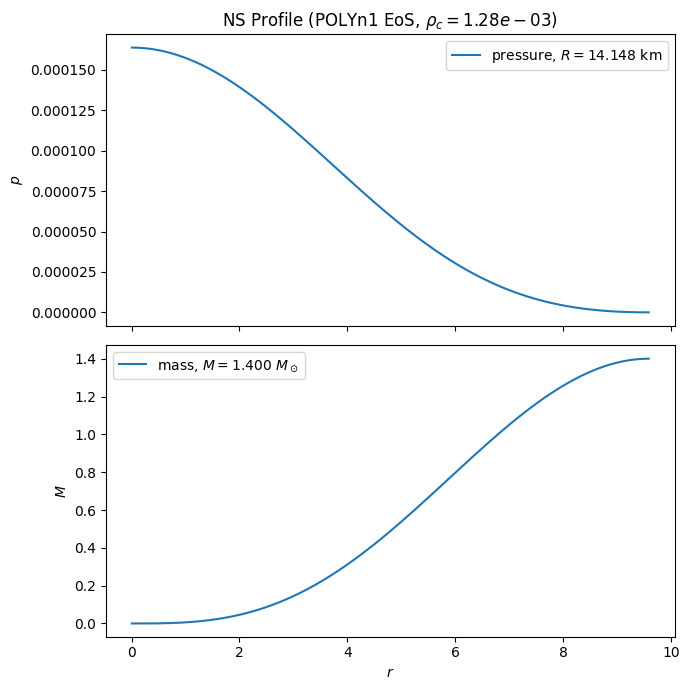

In [7]:

rho_c = 1.28e-3 #3.5 units of nuclear saturation 
p_central1 = eos_p(rho_c, 100, 2)
def eos_rho_POLY(p):
    return eos_rho(p, 100, 2)
def eos_cs2_POLY(p):
    return eos_cs2(p, 100, 2)

r, p, m, y2, = solve_tov_equations(                          
    p_central=p_central1,
    eos_rho=eos_rho_POLY,
    eos_cs2=eos_cs2_POLY,
    step=0.005
)

R = r[-1]
M = m[-1]

   #Plotting
fig, axes = plt.subplots(figsize=(7, 7), nrows=2, sharex=True)

axes[0].plot(r, p, label=r"pressure, $R = {:.3f}$".format(R*1.476)+" km")
axes[1].plot(r, m, label=r"mass, $M = {:.3f}$".format(M)+" $M_\odot$")

axes[0].set_title(r"NS Profile (POLYn1 EoS, $\rho_c = {:.2e}$".format(rho_c)+")")
axes[0].set_ylabel(r"$p$")
axes[0].legend()

axes[1].set_ylabel(r"$M$")
axes[1].legend()
axes[1].set_xlabel(r"$r$")

fig.tight_layout()
plt.show()

#fig.savefig("NS_POLYn1_profs_with_spin.png", bbox_inches='tight', dpi=300)

## Mass-Radius-Lambda Data Compiling

In [8]:
#By varying the central density, we obtain possible values for mass, radius, and log ratio: 

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 6 * rho_base

def POLYn1_eos_MRLY(eos_p,
                   eos_rho,
                   eos_cs2,
                   rho_central_start=rho_min,
                   rho_central_log_step=0.05,
                   rho_central_stop=rho_max,
                   stop_at_maximum_mass=False):

    data = pd.DataFrame(columns=['rho_central', 'M', 'R', 'Lambda2']).set_index('rho_central')
    rho_central = rho_central_start
    while rho_central < rho_central_stop:
        # Central pressure
        p_central = eos_p(rho_central)
        # Solve TOV + tidal
        r, p, m, y2 = solve_tov_equations(
            p_central=p_central,
            eos_rho=eos_rho,
            eos_cs2=eos_cs2,
            step=0.001)

        R = r[-1]
        M = m[-1]
        Y2 = y2[-1] 

        C = M / R

        if C < 1e-10:
            k2 = np.nan
        else:
            log = np.log(1 - 2*C)

            k2=((8 * C**5 / 5) * (1 - 2*C)**2 * (2 + 2*C*(Y2 - 1) - Y2))/((2*C*(6 - 3*Y2 + 3*C*(5*Y2 - 8)) +
        4*C**3*(13 - 11*Y2 + C*(3*Y2 - 2) + 2*C**2*(1 + Y2)) +
        3*(1 - 2*C)**2 * (2 - Y2 + 2*C*(Y2 - 1)) * log))
            
        if np.isfinite(k2) and k2 > 0:
                Lambda2 = (2/3) * k2 / C**5
        else:
                Lambda2 = np.nan
                
        if stop_at_maximum_mass and len(data) > 0:
            if M < data['M'].iat[-1]:
                break

        data.loc[rho_central] = [M, R, Lambda2]

        rho_central += rho_central * rho_central_log_step
    return data

eos_p_func, eos_rho_func = POLYn1_eos_p_and_rho()
eos_cs2_func, _ = POLYn1_eos_cs2_and_rho()

POLYn1_data = POLYn1_eos_MRLY(eos_p=eos_p_func,
                              eos_rho=eos_rho_func,
                              eos_cs2=eos_cs2_func,
                              );


/tmp/ipykernel_5454/554934993.py:8: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_5454/554934993.py:8: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_5454/554934993.py:8: RuntimeWarning: invalid value encountered in scalar power
  rho_rest = (p / K)**(1/Gamma)
/home/noahmackay97/.venv/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/tmp/ipykernel_5454/554934993.py:8: RuntimeWar

In [14]:
#Extract data
rho_vals = POLYn1_data.index.values
M_vals = POLYn1_data['M'].values
R_vals = POLYn1_data['R'].values
Lambda_vals = POLYn1_data['Lambda2'].values

#CoRe data
polyn1 = np.loadtxt('g2k100_mvsr.dat')
pfD = pd.DataFrame(polyn1, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
dataM_POLYn1 = pfD["M"].to_numpy()
dataR_POLYn1 = pfD["R"].to_numpy()
dataL_POLYn1 = pfD["Lambda"].to_numpy()


### Mass-Radius Curve

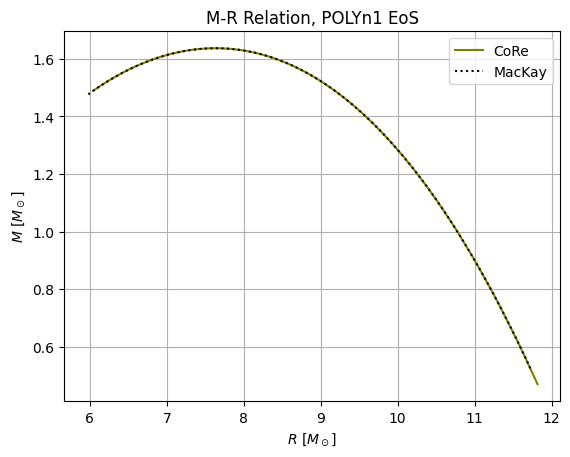

In [18]:
f = plt.figure()

plt.plot(dataR_POLYn1, dataM_POLYn1, label=r"CoRe",color='olive')
plt.plot(R_vals,M_vals,ls=':',label=r"MacKay",color='black');
plt.xlabel("$R$ [$M_\odot$]")
plt.ylabel("$M$ [$M_\odot$]")
plt.grid()
plt.title("M-R Relation, POLYn1 EoS")
plt.legend();

### Mass-Lambda curve

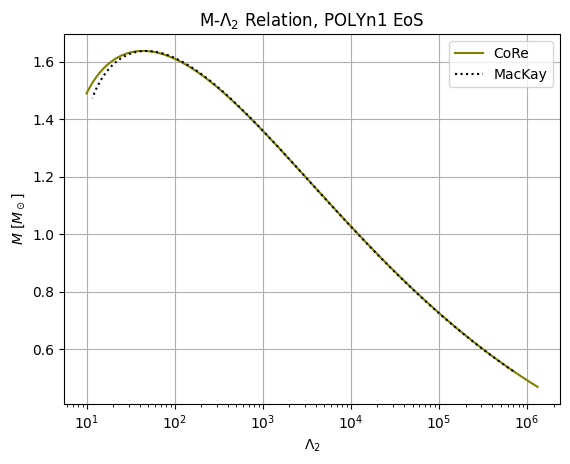

In [20]:
f = plt.figure()

plt.semilogx(dataL_POLYn1, dataM_POLYn1, label=r"CoRe",color='olive')
plt.semilogx(Lambda_vals,M_vals,ls=':',label=r"MacKay",color='black');
plt.xlabel("$\Lambda_2$")
plt.ylabel("$M$ [$M_\odot$]")
plt.grid()
plt.title("M-$\Lambda_2$ Relation, POLYn1 EoS")
plt.legend();

## Making a .dat file

In [12]:
#Turning extrapolated data into .dat files
#dfA.to_csv(f"POLYn1_MacKay.dat",
 #          sep=' ',          # space-separated (standard in physics)
  #         index=True,       # keeps rho_central
   #        header=True
    #      )